# Internship Task By DECODELABS

### ONLINE STORE DATASET

#### Importing libraries


In [1]:
import pandas as pd #for data manipulation and analysis
import matplotlib.pyplot as plt #for data visualization
import seaborn as sns #for data visualization
import numpy as np #for numerical operations

## Task 1
#### DATA COLLECTION AND DATASET UNDERSTANDING

In [2]:
df = pd.read_excel("Data\\Online-Store-Orders.xlsx")
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [ ]:
print("data info:")
print(df.info())

data info:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(

In [ ]:
print("data description:")
print(df.describe())

data description:
                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


In [ ]:
print("null values:")
print(df.isnull().sum())

null values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [6]:
print("duplicated values:")
print(df.duplicated().sum())

duplicated values:
0


## Task 2 
#### DATA CLEANING & PREPROCESSING

In [7]:
print(df.isnull().sum().sum())
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

309


In [8]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

## Task 3
#### EDA Exploratory Data Analysis

In [9]:
print(df['TotalPrice'].describe())


count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64


In [10]:
print(df['Product'].value_counts())


Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


In [11]:
print(df['PaymentMethod'].value_counts())


PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [12]:
print(df['ReferralSource'].value_counts())


ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


In [13]:

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()
monthly_sales = df.groupby('Month')['TotalPrice'].sum()


In [14]:
print(monthly_sales)
print(monthly_sales.idxmax())

Month
April        109186.05
August        86343.21
December      82540.50
February     112344.78
January      124313.23
July          85784.64
June         170616.13
March        123840.93
May          135142.59
November      75493.43
October       89834.82
September     69321.65
Name: TotalPrice, dtype: float64
June


## Task 4
#### DATA VISUALIZATION 

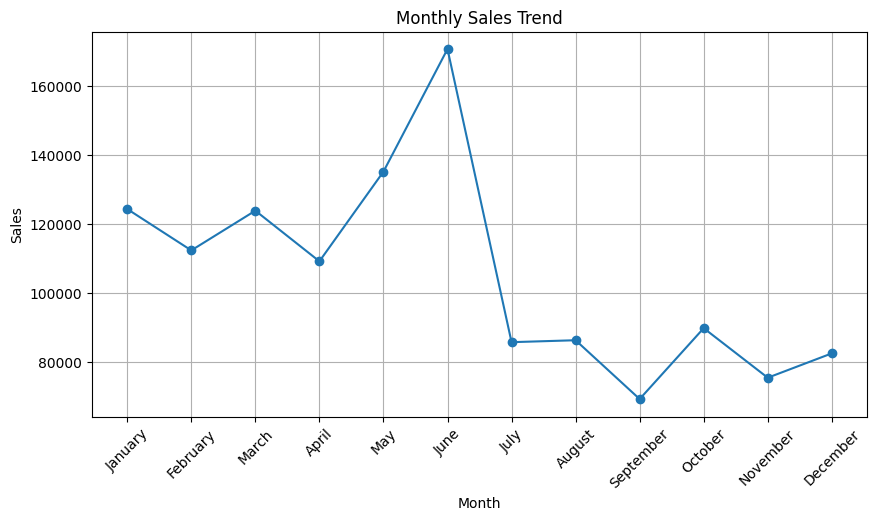

In [15]:
months = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]

values = [124313.23,112344.78,123840.93,109186.05,135142.59,
          170616.13,85784.64,86343.21,69321.65,89834.82,75493.43,82540.50]

plt.figure(figsize=(10,5))
plt.plot(months, values, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


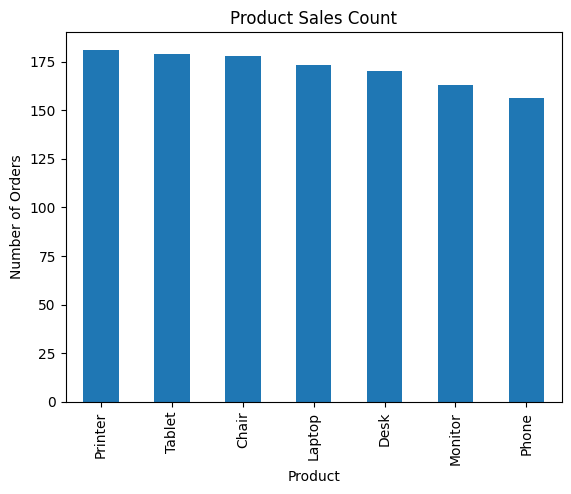

In [16]:
df["Product"].value_counts().plot(kind="bar")

plt.title("Product Sales Count")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.show()

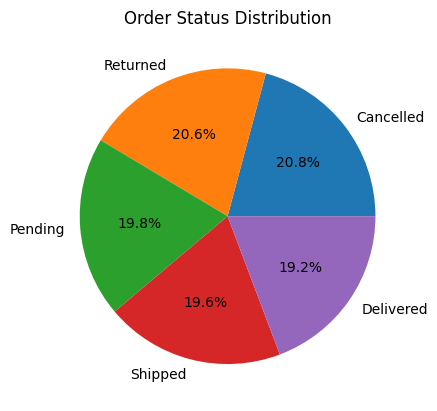

In [17]:
df["OrderStatus"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Order Status Distribution")
plt.ylabel("")

plt.show()

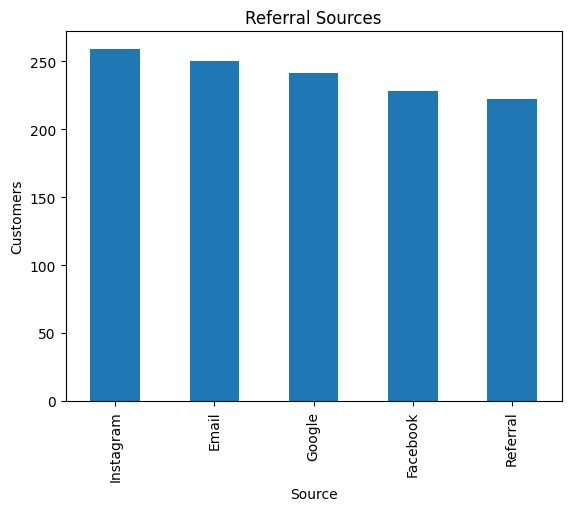

In [18]:
df["ReferralSource"].value_counts().plot(kind="bar")

plt.title("Referral Sources")
plt.xlabel("Source")
plt.ylabel("Customers")

plt.show()

### INSIGHTS


-Instagram is the most used refrral soursce

-June is the month with higest sale

-Cancellation and return rates are slightly higher than delivered orders.

-Printer is the most selled product

-